In [ ]:
import os
import numpy as np
from ase import io
from ase.atoms import Atoms
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import glob
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context("notebook")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
    "text.latex.preamble": r"\usepackage{sfmath}"})

In [5]:
# collect total energies from OUTCARs and compute corrected per-atom values

# reference energies per atom (eV)
atomic_refs = {"Li": -0.72092046, "Ni": -6.83535515, "O": -2.95452644}
#atomic_refs = {"Li": 0, "Ni": 0, "O": 0}


def collect_outcar_data(base_dir, subpattern="s*"):
    """Return a DataFrame with energies and volumes for each OUTCAR.
    …
    """
    entries = []
    pattern = os.path.join(base_dir, subpattern, "OUTCAR")
    for filepath in glob.glob(pattern):
        atoms = io.read(filepath, format="vasp-out")
        e_tot = atoms.get_potential_energy()
        nat = len(atoms)
        vol = atoms.get_volume()
        symbols = atoms.get_chemical_symbols()
        counts = {}
        for s in symbols:
            counts[s] = counts.get(s, 0) + 1
        ref_total = sum(counts.get(el, 0) * atomic_refs.get(el, 0)
                        for el in counts)
        entries.append({
            "path": filepath,
            "energy": e_tot,
            "energy_per_atom": e_tot / nat,
            "corr_energy_per_atom": (e_tot - ref_total) / nat,
            "volume": vol,
            "vol_per_atom": vol / nat,
            **counts,
        })

    return pd.DataFrame(entries)


# --------------------------------------------------
# Birch–Murnaghan equation of state
# --------------------------------------------------

EV_A3_TO_GPA = 160.21766208  # 1 eV/Å^3 = 160.21766208 GPa

def birch_murnaghan_energy(V, E0, V0, K0, K0p):
    eta = (V0 / V) ** (2 / 3)
    return E0 + (9 * V0 * K0 / 16) * ((eta - 1) ** 3 * K0p + (eta - 1) ** 2 * (6 - 4 * eta))

# --------------------------------------------------
# Fit helper
# --------------------------------------------------
def fit_bm_from_df(df_in, label="data"):
    d = df_in[["V_per_atom_A3", "E_per_atom_eV"]].dropna()
    V, E = d["V_per_atom_A3"].to_numpy(), d["E_per_atom_eV"].to_numpy()
    o = np.argsort(V); V, E = V[o], E[o]
    p0 = [E.min(), V[np.argmin(E)], 180.0, 4.0]  # E0, V0, K0(eV/A^3), K0'
    params, cov = curve_fit(birch_murnaghan_energy, V, E, p0=p0, maxfev=10000)
    std = np.sqrt(np.diag(cov))
    E_pred = birch_murnaghan_energy(V, *params)
    r2 = r2_score(E, E_pred)
    return dict(label=label, V=V, E=E, params=params, std=std, cov=cov, R2=r2)

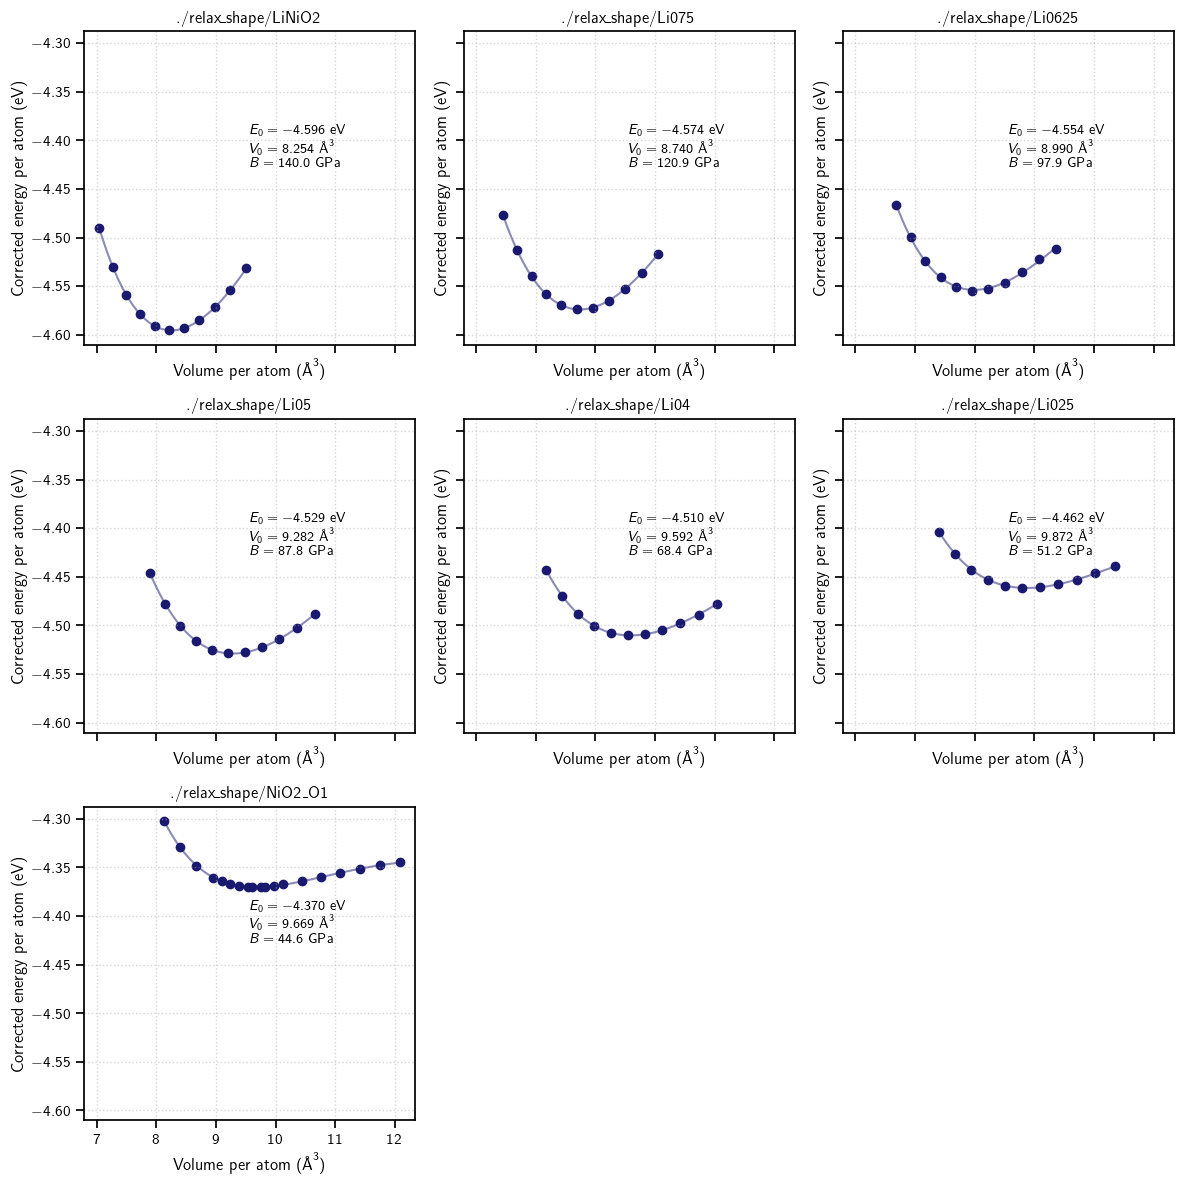

In [6]:
# loop over every subfolder, compute energies, and plot in a grid
base_dirs = [os.path.join('./relax_shape/', d) for d in os.listdir('./relax_shape/') if os.path.isdir(os.path.join('./relax_shape/', d))]

# gather dataframes and compute Li/Ni ratios
panels = []
for d in base_dirs:
    df_d = collect_outcar_data(d, subpattern="s*")
    if df_d.empty:
        continue
    # assume composition is constant within each directory
    nLi = df_d.get('Li', pd.Series([0])).iloc[0]
    nNi = df_d.get('Ni', pd.Series([0])).iloc[0]
    ratio = nLi / nNi if nNi != 0 else np.inf
    panels.append((d, ratio, df_d))

# sort by decreasing Li/Ni fraction
panels.sort(key=lambda x: x[1], reverse=True)

# determine grid shape (use square-ish layout)
num = len(panels)
if num == 0:
    print("No directories with data found.")
else:
    cols = int(np.ceil(np.sqrt(num)))
    rows = int(np.ceil(num / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    for ax, item in zip(axes.ravel(), panels):
        d, ratio, df_d = item
        ax.scatter(df_d['vol_per_atom'], df_d['corr_energy_per_atom'], c='midnightblue')
        ax.set_title(f"{d}")
        ax.set_xlabel(r'Volume per atom ($\mathrm{\AA}^3$)')
        ax.set_ylabel(r'Corrected energy per atom (eV)')
        ax.grid(ls=":", alpha=0.5)

        # equation-of-state fit to corrected per-atom energies
        vols = df_d['vol_per_atom'].values
        engs = df_d['corr_energy_per_atom'].values
        if len(vols) >= 3:
            p0 = [engs.min(), vols[np.argmin(engs)], 180.0, 4.0]
            try:
                params, cov = curve_fit(birch_murnaghan_energy, vols, engs, p0=p0, maxfev=10000)
                e0, v0, K0, K0p = params
                B_gpa = K0 * EV_A3_TO_GPA

                vfit = np.linspace(vols.min(), vols.max(), 200)
                efit = birch_murnaghan_energy(vfit, e0, v0, K0, K0p)
                ax.plot(vfit, efit, '-', color='midnightblue', alpha=0.5)
                textstr = (
                    r"$E_0={:.3f}\ \mathrm{{eV}}$".format(e0) + "\n" +
                    r"$V_0={:.3f}\ \mathrm{{\AA}}^3$".format(v0) + "\n" +
                    r"$B={:.1f}\ \mathrm{{GPa}}$".format(B_gpa)
                )
                ax.text(0.5, 0.7, textstr, transform=ax.transAxes, va='top', fontsize='small')
            except Exception as e:
                print(f"Warning: fit failed for {d}: {e}")


    # hide any unused subplots
    for ax in axes.ravel()[len(panels):]:
        ax.set_visible(False)

plt.tight_layout()
plt.show()